In [1]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

In [2]:
folder = "/work/bd0620/b309199/linear-mws"
flavor = "pmap_ld"
# flavor = "pmap_ppm"
# flavor = "eulag_compressi"
# flavor = "eulag_anelastic"

image_folder = f"../data/pmap"
os.makedirs(image_folder,exist_ok=True)

sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", f"{flavor}_MW_010km", 
        f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
        f"{flavor}_MW_125km", f"{flavor}_MW_150km"]

sims = [f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_005km", f"{flavor}_MW_010km", 
        f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km"]

labels = [f"L: 1$\,$km", f"L: 2$\,$km", f"L: 5$\,$km", f"L: 10$\,$km", f"L: 25$\,$km", f"L: 50$\,$km", f"L: 75$\,$km", f"L: 100$\,$km"]

# f"{flavor}_tau2_MW_003km"

In [3]:
ds_list = []
cfgs = []
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        cfgs.append(cfg)
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    ds_list.append(ds)

color_palette = [
    "#D72638",  # Crimson Red - Primary
    "#F46036",  # Coral Orange - Accent
    "#F6AE2D",  # Golden Sand - Highlight
    "mediumorchid",  # Teal Green - Complementary
    "#2F2F2F",  # Charcoal Gray - Neutral Base
    "grey",  # Mist White - Light Neutral
    "#58A4B0",  # Sky Blue - Cool Accent
    "#133C55"   # Midnight Blue - Deep Shade
]

if model == "pmap":
    U = cfg['ambient_fields']['velocity_x']
    grav = cfg['constants']['gravity0']
    stb00 = cfg['ambient_fields']['stb00']
    N = np.sqrt(stb00*grav)
    rho00 = cfg['ambient_fields']['rho00']
    AMP = cfg['define_orography']['args']['amplitude']
    f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
    print(cfg['constants'])
else:
    U = ds['u'][0,0].values
    grav = ds.g
    stb00 = ds.st
    N = np.sqrt(stb00*grav)
    rho00 = 1
    # rho00 = ds['rh0'][0,0,0].values
    AMP = ds.amp
    f = ds.fcr0 * np.sin(ds.ang*np.pi/180)

# [i for i in ds.variables] 

{'radius_sphere': 6368000.0, 'gravity0': 9.806159973144531, 'Ravo': 6.022136680382177e+23, 'Rbol': 1.380658045430573e-23, 'Rmd': 28.964399337768555, 'Rmv': 18.015300750732422, 'gamma': 1.399999976158142, 'p0': 100000.0, 't0': 288.0, 'tht0': 288.0, 'ee0': 611.0, 't_melt': 273.1600036621094, 'latheat_melt': 333700.0, 'latheat_sub': 2834500.0, 'latheat_vap': 2530000.0, 'fcoriolis0': 0.00014583999291062355, 'angle0': 43.290000915527344, 'lat_geonp': 90.0, 'lon_geonp': 180.0, 'gamma_geonp': 0.0, 'R': 8.314511458452216, 'Rd': 287.0596887403906, 'cpd': 1004.7089533665966, 'Rd_cpd': 0.2857142735500723, 'cap': 0.2857142735500723}


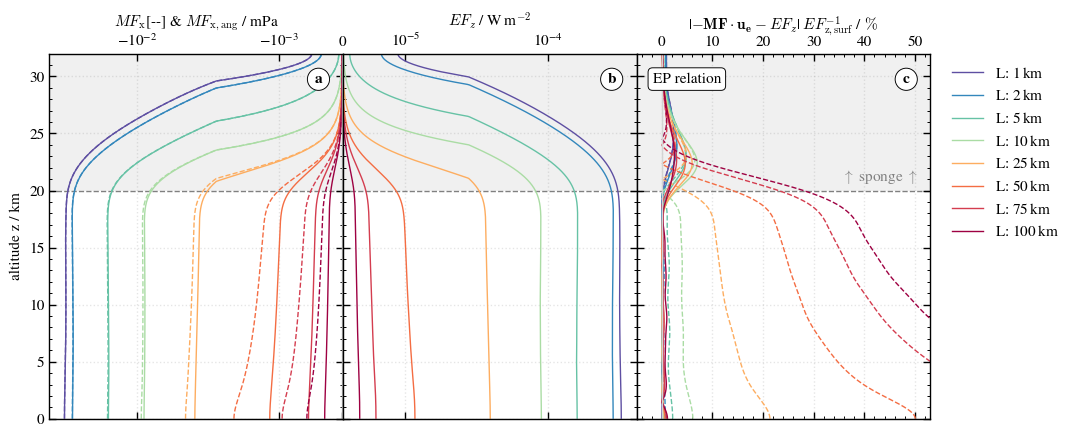

In [10]:
gskw = {'wspace':0, 'width_ratios': [4,4,4,2]}
fig, axes = plt.subplots(1,4,figsize=(11,4.5),sharey=True, gridspec_kw=gskw)

ax0 = axes[0]
ax1 = axes[1]
ax2 = axes[2]
ax3 = axes[3]
ax3.axis('off')

num_colors = 11
cmap = plt.get_cmap('Spectral')
COLS = [cmap(i / (num_colors - 1)) for i in range(num_colors)]
npop = 4
COLS.pop(npop)
COLS.pop(npop)
COLS.pop(npop)
COLS = COLS[::-1]
# COLS=['darkblue','slateblue','darkviolet', 'mediumorchid', 'lightcoral','tomato', 'firebrick', 'black']
ZLIM = [0,32]

abs_factor = 1
i=0
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        u0 = cfg['ambient_fields']['velocity_x']
        grav = cfg['constants']['gravity0']
        stb00 = cfg['ambient_fields']['stb00']
        N = np.sqrt(stb00*grav)
        rho00 = cfg['ambient_fields']['rho00']
        p00 = cfg['ambient_fields']['p00']
        # AMP = cfg['define_orography']['args']['amplitude']
        f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
        cap = cfg['constants']['cap']

        if cfg['absorber']['xboundaries']:
            nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
            nrelax1 = cfg['nx'] - nrelax0
        else:
            nrelax0 = 0
            nrelax1 = cfg['nx']
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    
    zcr = ds['zcr'][:,0].values / 1000

    u = ds['u'].values
    uprime = u - u0
    v = ds['v'].values
    vprime = v
    w = ds['w'].values
    rho = ds['rho'].values
    th = ds['th'].values
    thprime = ds['thprime'].values
    p = ds['p'].values
    pprime = ds['pprime'].values
    
    the = th - thprime
    dthdz = np.gradient(the, cfg['dz'], axis=0)
    
    # --------- Calculate fluxes -------------------- # 
    uw   = w * uprime
    vw   = w * vprime
    mfx  = rho * uw
    mfx_ang = rho * (uw - f * vprime * thprime / dthdz)
    mfy  = rho * vw
    mfy_ang = rho * (vw + f * uprime * thprime / dthdz)
    MF_U = mfx * u + mfy * v # = -EFz
    MF_U_ang = mfx_ang * u + mfy_ang * v
    
    efx = uprime * pprime # h14, EFx1
    efy = vprime * pprime
    # efx = np.sqrt(efx**2+efy**2)
    efz = w * pprime # h13, EFz1

    tte = the * (p/p00)**cap # T_env (TODO: use pr0 instead of p)
    tloc = th * (p/p00)**cap # T
    # tte = the * (p/p00)**ds.cap # T_env (TODO: use pr0 instead of p)
    # tloc = th * (p/p00)**ds.cap # T
    tprime = tloc-tte
    
    ek = 1/2 * (uprime**2 + vprime**2 + w**2)
    ep = 1/2*(grav/N)**2 * (tprime/tte)**2 # * ds['rh0'][t,:,y,:] #  potential energy density
    # --------- Calculate fluxes -------------------- # 
        
    # -> horizontal mean
    # uw_m = uw[:,nrelax0:nrelax1].mean(axis=1)
    # vw_m = vw[:,nrelax0:nrelax1].mean(axis=1)
    mfx_m = mfx[:,nrelax0:nrelax1].mean(axis=1)
    mfx_ang_m = mfx_ang[:,nrelax0:nrelax1].mean(axis=1)
    mfy_m = mfy[:,nrelax0:nrelax1].mean(axis=1)
    mfy_ang_m = mfy_ang[:,nrelax0:nrelax1].mean(axis=1)
    ep_m = ep[:,nrelax0:nrelax1].mean(axis=1)
    ek_m = ek[:,nrelax0:nrelax1].mean(axis=1)
    efx_m = efx[:,nrelax0:nrelax1].mean(axis=1)
    efy_m = efy[:,nrelax0:nrelax1].mean(axis=1)
    efz_m = efz[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_m = MF_U[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_ang_m = MF_U_ang[:,nrelax0:nrelax1].mean(axis=1)
    
     # --- 1D filter --- #
    dz = 50
    lambdaz = 6250

    mfx_m = filter.gaussian_filter_fft_1D(mfx_m, lambdaz, dz)
    mfx_ang_m = filter.gaussian_filter_fft_1D(mfx_ang_m, lambdaz, dz)
    mfy_m = filter.gaussian_filter_fft_1D(mfy_m, lambdaz, dz)
    mfy_ang_m = filter.gaussian_filter_fft_1D(mfy_ang_m, lambdaz, dz)

    ep_m = filter.gaussian_filter_fft_1D(ep_m, lambdaz, dz)
    efx_m = filter.gaussian_filter_fft_1D(efx_m, lambdaz, dz)
    efy_m = filter.gaussian_filter_fft_1D(efy_m, lambdaz, dz)
    efz_m = filter.gaussian_filter_fft_1D(efz_m, lambdaz, dz)
    MF_U_m = filter.gaussian_filter_fft_1D(MF_U_m, lambdaz, dz)
    MF_U_ang_m = filter.gaussian_filter_fft_1D(MF_U_ang_m, lambdaz, dz)
    ek_m = filter.gaussian_filter_fft_1D(ek_m, lambdaz, dz)

    delta_ep = (-efz_m-MF_U_m)/efz_m[0]*100
    delta_ep_ang = (-efz_m-MF_U_ang_m)/efz_m[0]*100
    
    # -- VISUALIZATION -- #
    lw = 1
    ax0.plot(1000*mfx_m, zcr, lw=lw, ls='dashed', color=COLS[i], label=labels[i])
    ax0.plot(1000*mfx_ang_m, zcr, lw=lw, color=COLS[i], label=labels[i])

    ax1.plot(efz_m, zcr, lw=lw, label=labels[i], color=COLS[i])
    # ax1.plot(MF_U_m, zcr, lw=lw, color=COLS[i])
    # ax1.plot(MF_U_ang_m, zcr, lw=lw, ls='dashed', color=COLS[i])
    
    # ax3.plot(efx_m, zcr, lw=lw, color=COLS[i])
    # ax3.plot(efy_m, zcr, lw=lw, ls='dotted', color=COLS[i])
    
    ax2.plot(abs(delta_ep), zcr, lw=lw, ls='dashed', color=COLS[i]) # subtract absolute values!!!
    ax2.plot(abs(delta_ep_ang), zcr, lw=lw, color=COLS[i], label=labels[i])    
    
    i+=1
    
# -- FORMAT AXES -- #
ax0.set_xlabel(r'$MF_\mathrm{x}$[--] & $MF_\mathrm{x,ang}$ / mPa')
ax1.set_xlabel(r"$EF_z$ / W$\,$m$^{-2}$")
ax2.set_xlabel(r"|$-\mathbf{MF} \cdot \mathbf{u_e} - EF_z$| $EF_\mathrm{z,surf}^{-1}$ / $\%$")
# ax2.set_xlabel(r"EF$_x$ / W$ \, \mathrm{m}^{-2}$")
# ax3.set_xlabel(r"EF$_\mathrm{x}$ & EF$_y$ [$\cdot \cdot$] / W$ \, \mathrm{m}^{-2}$")
# ax3.set_xlabel('E$_P$ / J kg$^{-1}$')


ax0.yaxis.set_minor_locator(AutoMinorLocator())

for ax in axes:
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis="y", which='both', direction="inout", right=False)
    ax.tick_params(axis="x", which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.xaxis.set_label_position('top')
ax0.tick_params(axis="y", which='both', direction="in")

# - SPONGE LAYER - #
lw_ax = 1
lw_sponge = 1
hsponge = 20
sponge_label = r'$\uparrow$ sponge $\uparrow$'
ax2.text(0.7, 0.65, sponge_label, transform=ax2.transAxes, color='grey')
c3 = 'lightgrey'
htop = 32
alpha_sponge = 0.33
symb_ax = '-'
col_ax = 'lightgrey'

# --- Labels and legend --- #
# ax2.legend(loc='outside upper right', framealpha=1, fontsize=11) # 'upper left'
# ax5.axis('off')
handles, labels = ax2.get_legend_handles_labels()

fig.legend(handles, labels, loc="upper center", framealpha=0,
           bbox_to_anchor=(0.92, 0.87))


ax0.set_ylim(ZLIM)
ax0.set_ylabel(r'altitude z / km')

ax0.set_xlim([-0.06,0.00001]) # MFxd
# ax0.set_xscale('log', linthresh=0.002)
ax0.set_xscale('symlog', linthresh=0.002)
# ax2.set_xlim([-0.0034,0.0008]) # EFx

ax1.set_xlim([0.0000001,0.0006]) # EFz
ax1.set_xscale('symlog', linthresh=0.00002)

ax2.set_xlim([-5,53]) # Delta

# --- Text --- #
labs = ['a','b','c']
for ax, lab in zip(axes[:-1], labs):
    ax.text(1-0.07, 0.92, lab, horizontalalignment='right', transform=ax.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    # ax.tick_params(axis="y", which='both', direction="inout", right=False)
    ax.tick_params(axis="x", which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis="y", which='both', direction="in", right=True)
    ax.tick_params(axis="x", which='both', top=True, bottom=True)
    ax.grid(visible=True)

    if ax in [ax2]:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    
    ax.fill_between(ax.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)
    ax.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)
    ax.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)
    ax.axhline(y=hsponge, lw=lw_sponge, ls='--', color='grey',zorder=0)

zl = 0.92
ax2.text(0.055, zl, 'EP relation', horizontalalignment='left', transform=ax2.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

# --- Save figure --- #
fig.tight_layout()
fig_title = f'vp_ep_temp.png'
# fig_title = f'vertical_profiles_legend.png'
fig.savefig(os.path.join(image_folder, fig_title), facecolor='w', edgecolor='w',
                    format='png', dpi=300, bbox_inches='tight')

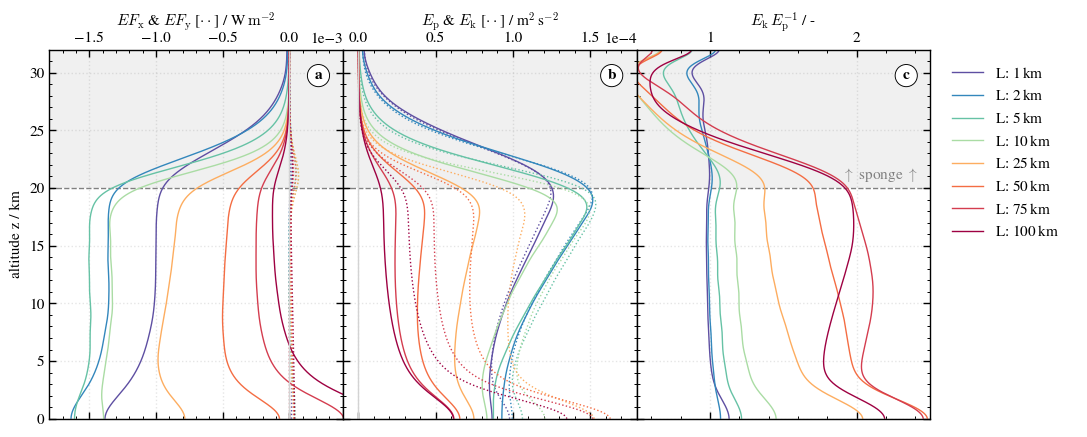

In [11]:
gskw = {'wspace':0, 'width_ratios': [4,4,4,2]}
fig, axes = plt.subplots(1,4,figsize=(11,4.5),sharey=True, gridspec_kw=gskw)

ax0 = axes[0]
ax1 = axes[1]
ax2 = axes[2]
ax3 = axes[3]
ax3.axis('off')

num_colors = 11
cmap = plt.get_cmap('Spectral')
COLS = [cmap(i / (num_colors - 1)) for i in range(num_colors)]
npop = 4
COLS.pop(npop)
COLS.pop(npop)
COLS.pop(npop)
COLS = COLS[::-1]
# COLS=['darkblue','slateblue','darkviolet', 'mediumorchid', 'lightcoral','tomato', 'firebrick', 'black']
ZLIM = [0,32]

abs_factor = 1
i=0
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        u0 = cfg['ambient_fields']['velocity_x']
        grav = cfg['constants']['gravity0']
        stb00 = cfg['ambient_fields']['stb00']
        N = np.sqrt(stb00*grav)
        rho00 = cfg['ambient_fields']['rho00']
        p00 = cfg['ambient_fields']['p00']
        # AMP = cfg['define_orography']['args']['amplitude']
        f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
        cap = cfg['constants']['cap']

        if cfg['absorber']['xboundaries']:
            nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
            nrelax1 = cfg['nx'] - nrelax0
        else:
            nrelax0 = 0
            nrelax1 = cfg['nx']
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    
    zcr = ds['zcr'][:,0].values / 1000

    u = ds['u'].values
    uprime = u - u0
    v = ds['v'].values
    vprime = v
    w = ds['w'].values
    rho = ds['rho'].values
    th = ds['th'].values
    thprime = ds['thprime'].values
    p = ds['p'].values
    pprime = ds['pprime'].values
    
    the = th - thprime
    dthdz = np.gradient(the, cfg['dz'], axis=0)
    
    # --------- Calculate fluxes -------------------- # 
    uw   = w * uprime
    vw   = w * vprime
    mfx  = rho * uw
    mfx_ang = rho * (uw - f * vprime * thprime / dthdz)
    mfy  = rho * vw
    mfy_ang = rho * (vw + f * uprime * thprime / dthdz)
    MF_U = mfx * u + mfy * v # = -EFz
    MF_U_ang = mfx_ang * u + mfy_ang * v
    
    efx = uprime * pprime # h14, EFx1
    efy = vprime * pprime
    # efx = np.sqrt(efx**2+efy**2)
    efz = w * pprime # h13, EFz1

    tte = the * (p/p00)**cap # T_env (TODO: use pr0 instead of p)
    tloc = th * (p/p00)**cap # T
    # tte = the * (p/p00)**ds.cap # T_env (TODO: use pr0 instead of p)
    # tloc = th * (p/p00)**ds.cap # T
    tprime = tloc-tte
    
    ek = 1/2 * (uprime**2 + vprime**2 + w**2)
    ep = 1/2*(grav/N)**2 * (tprime/tte)**2 # * ds['rh0'][t,:,y,:] #  potential energy density
    # --------- Calculate fluxes -------------------- # 
        
    # -> horizontal mean
    # uw_m = uw[:,nrelax0:nrelax1].mean(axis=1)
    # vw_m = vw[:,nrelax0:nrelax1].mean(axis=1)
    mfx_m = mfx[:,nrelax0:nrelax1].mean(axis=1)
    mfx_ang_m = mfx_ang[:,nrelax0:nrelax1].mean(axis=1)
    mfy_m = mfy[:,nrelax0:nrelax1].mean(axis=1)
    mfy_ang_m = mfy_ang[:,nrelax0:nrelax1].mean(axis=1)
    ep_m = ep[:,nrelax0:nrelax1].mean(axis=1)
    ek_m = ek[:,nrelax0:nrelax1].mean(axis=1)
    efx_m = efx[:,nrelax0:nrelax1].mean(axis=1)
    efy_m = efy[:,nrelax0:nrelax1].mean(axis=1)
    efz_m = efz[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_m = MF_U[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_ang_m = MF_U_ang[:,nrelax0:nrelax1].mean(axis=1)
    
     # --- 1D filter --- #
    dz = 50
    lambdaz = 6250

    mfx_m = filter.gaussian_filter_fft_1D(mfx_m, lambdaz, dz)
    mfx_ang_m = filter.gaussian_filter_fft_1D(mfx_ang_m, lambdaz, dz)
    mfy_m = filter.gaussian_filter_fft_1D(mfy_m, lambdaz, dz)
    mfy_ang_m = filter.gaussian_filter_fft_1D(mfy_ang_m, lambdaz, dz)

    ep_m = filter.gaussian_filter_fft_1D(ep_m, lambdaz, dz)
    efx_m = filter.gaussian_filter_fft_1D(efx_m, lambdaz, dz)
    efy_m = filter.gaussian_filter_fft_1D(efy_m, lambdaz, dz)
    efz_m = filter.gaussian_filter_fft_1D(efz_m, lambdaz, dz)
    MF_U_m = filter.gaussian_filter_fft_1D(MF_U_m, lambdaz, dz)
    MF_U_ang_m = filter.gaussian_filter_fft_1D(MF_U_ang_m, lambdaz, dz)
    ek_m = filter.gaussian_filter_fft_1D(ek_m, lambdaz, dz)

    delta_ep = (-efz_m-MF_U_m)/efz_m[0]*100
    delta_ep_ang = (-efz_m-MF_U_ang_m)/efz_m[0]*100
    
    # -- VISUALIZATION -- #
    lw = 1    
    ax0.plot(efx_m, zcr, lw=lw, color=COLS[i])
    ax0.plot(efy_m, zcr, lw=lw, ls='dotted', color=COLS[i])
    ax1.plot(ep_m, zcr, lw=lw, label=labels[i], color=COLS[i])
    ax1.plot(ek_m, zcr, lw=lw, ls='dotted', color=COLS[i])
    ax2.plot(ek_m / ep_m, zcr, lw=1, label=labels[i], color=COLS[i]) # subtract absolute values!!!  
    
    i+=1
    
# -- FORMAT AXES -- #
ax0.set_xlabel(r"$EF_\mathrm{x}$ & $EF_\mathrm{y}$ [$\cdot \cdot$] / W$ \, \mathrm{m}^{-2}$")
ax1.set_xlabel(r'$E_\mathrm{p}$ & $E_\mathrm{k}$ [$\cdot \cdot$] / m$^2 \,$s$^{-2}$')
ax2.set_xlabel(r"$E_\mathrm{k} \, E_\mathrm{p}^{-1}$ / -")


ax0.yaxis.set_minor_locator(AutoMinorLocator())

# for ax in axes:
#     ax.xaxis.set_minor_locator(AutoMinorLocator())
#     ax.tick_params(axis="y", which='both', direction="inout", right=False)
#     ax.tick_params(axis="x", which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
#     ax.xaxis.set_label_position('top')
# ax0.tick_params(axis="y", which='both', direction="in")

# - SPONGE LAYER - #
lw_ax = 1
lw_sponge = 1
hsponge = 20
sponge_label = r'$\uparrow$ sponge $\uparrow$'
ax2.text(0.7, 0.65, sponge_label, transform=ax2.transAxes, color='grey')

c3 = 'lightgrey'
htop = 32
alpha_sponge = 0.33
symb_ax = '-'
col_ax = 'lightgrey'

# --- Labels and legend --- #
# ax2.legend(loc='outside upper right', framealpha=1, fontsize=11) # 'upper left'
# ax5.axis('off')
handles, labels = ax2.get_legend_handles_labels()

fig.legend(handles, labels, loc="upper center", framealpha=0,
           bbox_to_anchor=(0.92, 0.87))

ax0.set_ylim(ZLIM)
ax0.set_ylabel(r'altitude z / km')
ax0.set_xlim([-0.0018,0.0004]) # EFx
ax1.set_xlim([-0.00001,0.00018]) # Ep
ax2.set_xlim([0.5,2.5])
ax2.set_xticks([1,2])

# --- Text --- #
labs = ['a','b','c']
for ax, lab in zip(axes[:-1], labs):
    ax.text(1-0.07, 0.92, lab, horizontalalignment='right', transform=ax.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    # ax.tick_params(axis="y", which='both', direction="inout", right=False)
    ax.tick_params(axis="x", which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis="y", which='both', direction="in", right=True)
    ax.tick_params(axis="x", which='both', top=True, bottom=True)
    ax.grid(visible=True)

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    
    ax.fill_between(ax.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)
    ax.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)
    ax.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)
    ax.axhline(y=hsponge, lw=lw_sponge, ls='--', color='grey',zorder=0)
    
# --- Limits and Sci format --- #
for ax in [ax0, ax1]:
    ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,2))
    ax.figure.canvas.draw()  # Needed to populate offset text
    offset_text = ax.xaxis.get_offset_text()
    offset_text.set_visible(False)  # Hide default
    ax.annotate(offset_text.get_text(), xy=(1, 1.01), xycoords='axes fraction',
                ha='right', va='bottom')
    
# --- Save figure --- #
fig.tight_layout()
fig_title = f'vp_energy_temp.png'
# fig_title = f'vertical_profiles_legend.png'
fig.savefig(os.path.join(image_folder, fig_title), facecolor='w', edgecolor='w',
                    format='png', dpi=300, bbox_inches='tight')

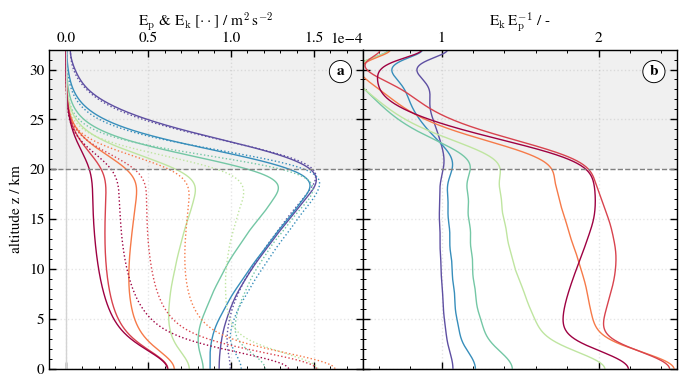

In [17]:
gskw = {'wspace':0}
fig, axes = plt.subplots(1,2,figsize=(7,4),sharey=True, gridspec_kw=gskw)

ax0 = axes[0]
ax1 = axes[1]

abs_factor = 1
i=0
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        u0 = cfg['ambient_fields']['velocity_x']
        grav = cfg['constants']['gravity0']
        stb00 = cfg['ambient_fields']['stb00']
        N = np.sqrt(stb00*grav)
        rho00 = cfg['ambient_fields']['rho00']
        p00 = cfg['ambient_fields']['p00']
        # AMP = cfg['define_orography']['args']['amplitude']
        f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
        cap = cfg['constants']['cap']

        if cfg['absorber']['xboundaries']:
            nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
            nrelax1 = cfg['nx'] - nrelax0
        else:
            nrelax0 = 0
            nrelax1 = cfg['nx']
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    
    zcr = ds['zcr'][:,0].values / 1000

    u = ds['u'].values
    uprime = u - u0
    v = ds['v'].values
    vprime = v
    w = ds['w'].values
    rho = ds['rho'].values
    th = ds['th'].values
    thprime = ds['thprime'].values
    p = ds['p'].values
    pprime = ds['pprime'].values
    
    the = th - thprime
    dthdz = np.gradient(the, cfg['dz'], axis=0)
    
    # --------- Calculate fluxes -------------------- # 
    uw   = w * uprime
    vw   = w * vprime
    mfx  = rho * uw
    mfx_ang = rho * (uw - f * vprime * thprime / dthdz)
    mfy  = rho * vw
    mfy_ang = rho * (vw + f * uprime * thprime / dthdz)
    MF_U = mfx * u + mfy * v # = -EFz
    MF_U_ang = mfx_ang * u + mfy_ang * v
    
    efx = uprime * pprime # h14, EFx1
    efy = vprime * pprime
    # efx = np.sqrt(efx**2+efy**2)
    efz = w * pprime # h13, EFz1

    tte = the * (p/p00)**cap # T_env (TODO: use pr0 instead of p)
    tloc = th * (p/p00)**cap # T
    # tte = the * (p/p00)**ds.cap # T_env (TODO: use pr0 instead of p)
    # tloc = th * (p/p00)**ds.cap # T
    tprime = tloc-tte
    
    ek = 1/2 * (uprime**2 + vprime**2 + w**2)
    ep = 1/2*(grav/N)**2 * (tprime/tte)**2 # * ds['rh0'][t,:,y,:] #  potential energy density
    # --------- Calculate fluxes -------------------- # 
        
    # -> horizontal mean
    mfx_m = mfx[:,nrelax0:nrelax1].mean(axis=1)
    mfx_ang_m = mfx_ang[:,nrelax0:nrelax1].mean(axis=1)
    # mfy_m = mfy[:,nrelax0:nrelax1].mean(axis=1)
    # mfy_ang_m = mfy_ang[:,nrelax0:nrelax1].mean(axis=1)
    ep_m = ep[:,nrelax0:nrelax1].mean(axis=1)
    ek_m = ek[:,nrelax0:nrelax1].mean(axis=1)
    efx_m = efx[:,nrelax0:nrelax1].mean(axis=1)
    efy_m = efy[:,nrelax0:nrelax1].mean(axis=1)
    efz_m = efz[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_m = MF_U[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_ang_m = MF_U_ang[:,nrelax0:nrelax1].mean(axis=1)
    
     # --- 1D filter --- #
    dz = 50
    lambdaz = 6250

    mfx_m = filter.gaussian_filter_fft_1D(mfx_m, lambdaz, dz)
    mfx_ang_m = filter.gaussian_filter_fft_1D(mfx_ang_m, lambdaz, dz)
    ep_m = filter.gaussian_filter_fft_1D(ep_m, lambdaz, dz)
    efx_m = filter.gaussian_filter_fft_1D(efx_m, lambdaz, dz)
    efy_m = filter.gaussian_filter_fft_1D(efy_m, lambdaz, dz)
    efz_m = filter.gaussian_filter_fft_1D(efz_m, lambdaz, dz)
    MF_U_m = filter.gaussian_filter_fft_1D(MF_U_m, lambdaz, dz)
    MF_U_ang_m = filter.gaussian_filter_fft_1D(MF_U_ang_m, lambdaz, dz)
    ek_m = filter.gaussian_filter_fft_1D(ek_m, lambdaz, dz)
    
    # -- VISUALIZATION -- #
    ax0.plot(ep_m, zcr, lw=lw, label=labels[i], color=COLS[i])
    ax0.plot(ek_m, zcr, lw=lw, ls='dotted', color=COLS[i])
    ax1.plot(ek_m / ep_m, zcr, lw=1, label=labels[i], color=COLS[i]) # subtract absolute values!!!
    
    i+=1
    
# -- FORMAT AXES -- #
ax0.set_xlabel(r'E$_\mathrm{p}$ & E$_\mathrm{k}$ [$\cdot \cdot$] / m$^2 \,$s$^{-2}$')
ax1.set_xlabel(r"E$_\mathrm{k}\,$E$_\mathrm{p}^{-1}$ / -")
ax0.set_ylim(ZLIM)
ax0.set_ylabel(r'altitude z / km')

# --- Limits and Sci format --- #
ax0.set_xlim([-0.00001,0.00018]) # Ep
ax1.set_xlim([0.5,2.5])
ax1.set_xticks([1,2])

# Format
c3 = 'lightgrey'
htop = 34
alpha_sponge = 0.33
symb_ax = '-'
col_ax = 'lightgrey'

lw_ax = 1
lw_sponge = 1
hsponge = 20

for ax in axes:
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.xaxis.set_minor_locator(AutoMinorLocator())

    # ax.tick_params(axis="y", which='both', direction="inout", right=False)
    ax.tick_params(axis="x", which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis="y", which='both', direction="in")
    ax.tick_params(axis="x", which='both', top=True, bottom=True)
    ax.grid(visible=True)
    
    ax.fill_between(ax.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)
    ax.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)
    ax.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)
    ax.hlines(y=hsponge, xmin=-20, xmax=200, lw=lw_sponge,ls='--',color='grey')

for ax in axes[0:1]:
    ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,2))
    ax.figure.canvas.draw()  # Needed to populate offset text
    offset_text = ax.xaxis.get_offset_text()
    offset_text.set_visible(False)  # Hide default
    ax.annotate(offset_text.get_text(), xy=(1, 1.01), xycoords='axes fraction',
                ha='right', va='bottom')
    
# --- Text --- #
zl = 0.92
xl = 1-0.06
ax0.text(xl, zl, 'a', horizontalalignment='right', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax1.text(xl, zl, 'b', horizontalalignment='right', transform=ax1.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

fig_title = f'vp_energy_temp.png'
fig.tight_layout()
fig.savefig(os.path.join(image_folder, fig_title), facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')